In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

In [2]:

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [3]:
print("="*80)
print("ANÁLISE EXPLORATÓRIA DE DADOS - HEPATITES VIRAIS (SINAN) - VERSÃO CORRIGIDA")
print("="*80)

ANÁLISE EXPLORATÓRIA DE DADOS - HEPATITES VIRAIS (SINAN) - VERSÃO CORRIGIDA


# Preparação dos dados


#### 1. CARREGAMENTO E FILTROS INICIAIS


In [4]:
from ipywidgets import interact

print("\n" + "="*80)
print("ETAPA 1: CARREGAMENTO E FILTROS INICIAIS")
print("="*80)

df_original = pd.read_parquet("SINAN_LEPT_2.parquet", engine="fastparquet")
df=df_original.copy()


ETAPA 1: CARREGAMENTO E FILTROS INICIAIS


Dicionário completo de variáveis do SINAN - Hepatites Virais

In [5]:
# 🔹 df_clean já carregado anteriormente
print(f"Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

#  Dicionário oficial de variáveis e descrições
descricao_variaveis = {
 # Identificação da Notificação
 'TP_NOT': {'descrição': 'Tipo de notificação',  'categorias': {1: 'Individual', 2: 'Surto'}},
 'ID_AGRAVO': {'descrição': 'Código do agravo (CID-10 da leptospirose)',  'categorias': {'A27.': 'Leptospirose',   'A279': 'Leptospirose nao especificada'}},
 'DT_NOTIFIC': {'descrição': 'Data da notificação do caso',  'categorias': None},
 'SEM_NOT': {'descrição': 'Semana epidemiológica da notificação',  'categorias': None},
 'NU_ANO': {'descrição': 'Ano da notificação', 'categorias': None},
  # Local da Notificação (com códigos IBGE)
 'SG_UF_NOT': {'descrição': 'UF de notificação (código IBGE)', 'categorias': {11: 'Rondônia (RO)',  12: 'Acre (AC)',  13: 'Amazonas (AM)',  14: 'Roraima (RR)',  15: 'Pará (PA)',  16: 'Amapá (AP)',  17: 'Tocantins (TO)',  21: 'Maranhão (MA)',  22: 'Piauí (PI)',  23: 'Ceará (CE)',  24: 'Rio Grande do Norte (RN)',  25: 'Paraíba (PB)',  26: 'Pernambuco (PE)',  27: 'Alagoas (AL)',  28: 'Sergipe (SE)',  29: 'Bahia (BA)',  31: 'Minas Gerais (MG)',  32: 'Espírito Santo (ES)',  33: 'Rio de Janeiro (RJ)',  35: 'São Paulo (SP)',  41: 'Paraná (PR)',  42: 'Santa Catarina (SC)',  43: 'Rio Grande do Sul (RS)',  50: 'Mato Grosso do Sul (MS)',  51: 'Mato Grosso (MT)',  52: 'Goiás (GO)',  53: 'Distrito Federal (DF)'}},
 'ID_MUNICIP': {'descrição': 'Código IBGE do município de notificação',  'categorias': None},
 'ID_REGIONA': {'descrição': 'Código da regional de saúde',  'categorias': None},
 'ID_UNIDADE': {'descrição': 'Código da unidade notificadora',  'categorias': None},

 # Dados do paciente
 'DT_SIN_PRI': {'descrição': 'Data de início dos primeiros sintomas',  'categorias': None},
 'SEM_PRI': {'descrição': 'Semana epidemiológica dos primeiros sintomas',  'categorias': None},
 'ANO_NASC': {'descrição': 'Ano de nascimento', 'categorias': None},
 'NU_IDADE_N': {'descrição': 'Idade em anos', 'categorias': None},
 'CS_SEXO': {'descrição': 'Sexo do paciente',  'categorias': {'M': 'Masculino', 'F': 'Feminino', 'I': 'Ignorado'}},
 'CS_GESTANT': {'descrição': 'Gestante', 'categorias': {1: '1º Trimestre',  2: '2º Trimestre',  3: '3º Trimestre',  4: 'Idade gestacional ignorada',  5: 'Não',6:'Não se aplica',  9: 'Ignorado'}},
 'CS_RACA': {'descrição': 'Raça/Cor', 'categorias': {1: 'Branca',  2: 'Preta',  3: 'Amarela',  4: 'Parda',  5: 'Indígena',  9: 'Ignorado'}},
 'CS_ESCOL_N': {'descrição': 'Escolaridade',  'categorias': {0: 'Sem escolaridade',   1: '1ª a 4ª série incompleta do EF',   2: '4ª série completa do EF',   3: '5ª a 8ª série incompleta do EF',   4: 'Ensino fundamental completo',   5: 'Ensino médio incompleto',   6: 'Ensino médio completo',   7: 'Superior incompleto',   8: 'Superior completo',   9: 'Ignorado'}},
 'SG_UF': {'descrição': 'UF de residência (código IBGE)',  'categorias': {11: 'RO',   12: 'AC',   13: 'AM',   14: 'RR',   15: 'PA',   16: 'AP',   17: 'TO',   21: 'MA',   22: 'PI',   23: 'CE',   24: 'RN',   25: 'PB',   26: 'PE',   27: 'AL',   28: 'SE',   29: 'BA',   31: 'MG',   32: 'ES',   33: 'RJ',   35: 'SP',   41: 'PR',   42: 'SC',   43: 'RS',   50: 'MS',   51: 'MT',   52: 'GO',   53: 'DF'}},
 'ID_MN_RESI': {'descrição': 'Código IBGE do município de residência',  'categorias': None},
 'ID_RG_RESI': {'descrição': 'Código da regional de residência',  'categorias': None},
 'ID_PAIS': {'descrição': 'Código do país de residência', 'categorias': None},
    
  # Histórico, ambiente e exposições   
 'ANT_CB_LAM': {'descrição': 'Contato com lama',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_CRI': {'descrição': 'Contato com criação de animais',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_CAI': {'descrição': 'Contato com cães',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_FOS': {'descrição': 'Contato com fossas',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_SIN': {'descrição': 'Contato com sinantrópicos',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_PLA': {'descrição': 'Contato com plantas/vegetação',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_COR': {'descrição': 'Contato com córrego, rio, lagoa',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_ROE': {'descrição': 'Contato com roedores',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_GRA': {'descrição': 'Contato com granja',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_TER': {'descrição': 'Contato com terra/barro',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_LIX': {'descrição': 'Contato com lixo',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_CB_OUT': {'descrição': 'Outros tipos de contato',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_OU_DES': {'descrição': 'Descrição de outro tipo de contato',  'categorias': None},
 'ANT_HUMANO': {'descrição': 'Contato com pessoas doentes',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'ANT_ANIMAI': {'descrição': 'Contato com animais infectados',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CON_AMBIEN': {'descrição': 'Ambiente provável de infecção',  'categorias': {1: 'Domicílio',   2: 'Trabalho',   3: 'Lazer',   4: 'Outro',   9: 'Ignorado'}},
  #  Sintomas clínicos 
 'CLI_FEBRE': {'descrição': 'Febre', 'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_MIALGI': {'descrição': 'Mialgia (dor muscular)',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_CEFALE': {'descrição': 'Cefaleia',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_PROST': {'descrição': 'Prostração',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_CONGES': {'descrição': 'Congestão conjuntival',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_PANTUR': {'descrição': 'Dor em panturrilhas',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_VOMITO': {'descrição': 'Vômitos',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_DIARRE': {'descrição': 'Diarreia',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_ICTERI': {'descrição': 'Icterícia',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_RENAL': {'descrição': 'Insuficiência renal',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_RESPIR': {'descrição': 'Sintomas respiratórios',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_CARDIA': {'descrição': 'Alterações cardíacas',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_HEMOPU': {'descrição': 'Hemoptise',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_HEMORR': {'descrição': 'Manifestações hemorrágicas',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_MENING': {'descrição': 'Meningite',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'CLI_OUTROS': {'descrição': 'Outros sintomas',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
  #  Atendimento e exames laboratoriais
 'ATE_HOSP': {'descrição': 'Houve internação hospitalar',  'categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'LAB_ELIS_1': {'descrição': 'Resultado ELISA 1ª amostra',  'categorias': {1: 'Reagente',   2: 'Não reagente',   3: 'Inconclusivo', 4:'Não Realizado',   9: 'Ignorado'}},
 'LAB_ELIS_2': {'descrição': 'Resultado ELISA 2ª amostra',  'categorias': {1: 'Reagente',   2: 'Não reagente',   3: 'Inconclusivo', 4:'Não Realizado',   9: 'Ignorado'}},
 'LAB_MICR_1': {'descrição': 'Resultado Micro 1ª amostra',  'categorias': {1: 'Reagente',   2: 'Não reagente',   3: 'Inconclusivo', 4:'Não Realizado',   9: 'Ignorado'}},
 'LAB_MICR_2': {'descrição': 'Resultado Micro 2ª amostra',  'categorias': {1: 'Reagente',   2: 'Não reagente',   3: 'Inconclusivo', 4:'Não Realizado',   9: 'Ignorado'}},
 'RES_ISOL': {'descrição': 'Resultado do isolamento',  'categorias': {1: 'Positivo', 2: 'Negativo',3: 'Inconclusivo', 4:'Não Realizado', 9: 'Ignorado'}},
 'RES_IMUNO': {'descrição': 'Resultado imunohistoquímico',  'categorias': {1: 'Positivo', 2: 'Negativo',3: 'Inconclusivo', 4:'Não Realizado', 9: 'Ignorado'}},
 'RES_PCR': {'descrição': 'Resultado do PCR',  'categorias': {1: 'Positivo', 2: 'Negativo',3: 'Inconclusivo', 4:'Não Realizado', 9: 'Ignorado'}},
  #  Encerramento e evolução
 'CLASSI_FIN': {'descrição': 'Classificação final',  'categorias': {1: 'Confirmado ',   2: 'Descartado',  8: 'Inconclusivo',   9: 'Ignorado'}},
 'CRITERIO': {'descrição': 'Critério de confirmação',  'categorias': {1: 'Laboratorial',   2: 'Clínico-epidemiológico',   3: 'Imagem',   9: 'Ignorado'}},
 'TPAUTOCTO': {'descrição': 'Indica se o caso é autóctone do município de residência',  'categorias': {1: 'Sim',   2: 'Não',   3: 'Indeterminado',   9: 'Ignorado'}},
 'COUFINF': {'descrição': 'UF provável de infecção (código IBGE)', 'categorias': {11: 'RO',  12: 'AC',  13: 'AM',  14: 'RR',  15: 'PA',  16: 'AP',  17: 'TO',  21: 'MA',  22: 'PI',  23: 'CE',  24: 'RN',  25: 'PB',  26: 'PE',  27: 'AL',  28: 'SE',  29: 'BA',  31: 'MG',  32: 'ES',  33: 'RJ',  35: 'SP',  41: 'PR',  42: 'SC',  43: 'RS',  50: 'MS',  51: 'MT',  52: 'GO',  53: 'DF'}},
 'CON_AREA': {'descrição': 'Zona de residência','categorias': {1: 'Urbana', 2: 'Rural', 3: 'Periurbana', 9: 'Ignorado'}},
 'DOENCA_TRA': {'descrição': 'Doença relacionada ao trabalho','categorias': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
 'EVOLUCAO': {'descrição': 'Evolução do caso', 'categorias': {1: 'Cura',  2: 'Óbito por leptospirose',  3: 'Óbito por outra causa',  9: 'Ignorado'}},
 'DT_OBITO': {'descrição': 'Data do óbito', 'categorias': None},
 'DT_ENCERRA': {'descrição': 'Data de encerramento', 'categorias': None},
  #  Fatores de risco (UFs codificadas IBGE) 
 'CO_UF_R1': {'descrição': 'UF do 1º fator de risco', 'categorias': {11: 'RO',  12: 'AC',  13: 'AM',  14: 'RR',  15: 'PA',  16: 'AP',  17: 'TO',  21: 'MA',  22: 'PI',  23: 'CE',  24: 'RN',  25: 'PB',  26: 'PE',  27: 'AL',  28: 'SE',  29: 'BA',  31: 'MG',  32: 'ES',  33: 'RJ',  35: 'SP',  41: 'PR',  42: 'SC',  43: 'RS',  50: 'MS',  51: 'MT',  52: 'GO',  53: 'DF'}},
 'CO_UF_R2': {'descrição': 'UF do 2º fator de risco', 'categorias': {11: 'RO',  12: 'AC',  13: 'AM',  14: 'RR',  15: 'PA',  16: 'AP',  17: 'TO',  21: 'MA',  22: 'PI',  23: 'CE',  24: 'RN',  25: 'PB',  26: 'PE',  27: 'AL',  28: 'SE',  29: 'BA',  31: 'MG',  32: 'ES',  33: 'RJ',  35: 'SP',  41: 'PR',  42: 'SC',  43: 'RS',  50: 'MS',  51: 'MT',  52: 'GO',  53: 'DF'}},
 'CO_UF_R3': {'descrição': 'UF do 3º fator de risco', 'categorias': {11: 'RO',  12: 'AC',  13: 'AM',  14: 'RR',  15: 'PA',  16: 'AP',  17: 'TO',  21: 'MA',  22: 'PI',  23: 'CE',  24: 'RN',  25: 'PB',  26: 'PE',  27: 'AL',  28: 'SE',  29: 'BA',  31: 'MG',  32: 'ES',  33: 'RJ',  35: 'SP',  41: 'PR',  42: 'SC',  43: 'RS',  50: 'MS',  51: 'MT',  52: 'GO',  53: 'DF'}},
 'CO_UF_R4': {'descrição': 'UF do 4º fator de risco (código IBGE)','categorias': {11: 'RO',12: 'AC',13: 'AM',14: 'RR',15: 'PA',16: 'AP',17: 'TO',21: 'MA',22: 'PI',23: 'CE',24: 'RN',25: 'PB',26: 'PE',27: 'AL',28: 'SE',29: 'BA',31: 'MG',32: 'ES',33: 'RJ',35: 'SP',41: 'PR',42: 'SC',43: 'RS',50: 'MS',51: 'MT',52: 'GO',53: 'DF'}},
 'NU_LOTE_I': {'descrição': 'Número do lote de importação','categorias': None},
 'ano': {'descrição': 'Ano de referência consolidado', 'categorias': None}}

#  Criar DataFrame com variáveis existentes em df_clean
variaveis_presentes = [col for col in descricao_variaveis.keys() if col in df.columns]

dicionario_df = pd.DataFrame({
    "Variável": variaveis_presentes,
    "Descrição": [descricao_variaveis[v] for v in variaveis_presentes],
    "Exemplo de valor": [
        df[v].dropna().unique()[:3].tolist() if v in df.columns else [] for v in variaveis_presentes
    ]
})

#  Exibir o dicionário de dados
print("📋 Dicionário de Variáveis - Dataset SINAN Hepatites\n")
display(dicionario_df)

#  Exibir amostra real dessas variáveis
print("\n🔍 Amostra de dados (primeiras 5 linhas):")
display(df[variaveis_presentes].head())


Dataset carregado com 210949 linhas e 122 colunas.

📋 Dicionário de Variáveis - Dataset SINAN Hepatites



,Variável,Descrição,Exemplo de valor
0,TP_NOT,"{'descrição': 'Tipo de notificação', 'categori...",[2]
1,ID_AGRAVO,{'descrição': 'Código do agravo (CID-10 da lep...,"[A279, A27.]"
2,DT_NOTIFIC,"{'descrição': 'Data da notificação do caso', '...","[1356998400000000000, 1357084800000000000, 135..."
3,SEM_NOT,{'descrição': 'Semana epidemiológica da notifi...,"[201301, 1301 , 201302]"
4,NU_ANO,"{'descrição': 'Ano da notificação', 'categoria...","[2013, 2014, 2015]"
5,SG_UF_NOT,{'descrição': 'UF de notificação (código IBGE)...,"[35, 12, 23]"
6,ID_MUNICIP,{'descrição': 'Código IBGE do município de not...,"[354850, 355030, 350570]"
7,ID_REGIONA,"{'descrição': 'Código da regional de saúde', '...","[1349 , 1331 , 1335 ]"
8,ID_UNIDADE,{'descrição': 'Código da unidade notificadora'...,"[2025760, 2786680, 2082209]"
9,DT_SIN_PRI,{'descrição': 'Data de início dos primeiros si...,"[1356566400000000000, 1356307200000000000, 135..."



🔍 Amostra de dados (primeiras 5 linhas):


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,ANT_CB_LAM,ANT_CB_CRI,ANT_CB_CAI,ANT_CB_FOS,ANT_CB_SIN,ANT_CB_PLA,ANT_CB_COR,ANT_CB_ROE,ANT_CB_GRA,ANT_CB_TER,ANT_CB_LIX,ANT_CB_OUT,ANT_OU_DES,ANT_HUMANO,ANT_ANIMAI,CON_AMBIEN,CLI_FEBRE,CLI_MIALGI,CLI_CEFALE,CLI_PROST,CLI_CONGES,CLI_PANTUR,CLI_VOMITO,CLI_DIARRE,CLI_ICTERI,CLI_RENAL,CLI_RESPIR,CLI_CARDIA,CLI_HEMOPU,CLI_HEMORR,CLI_MENING,CLI_OUTROS,ATE_HOSP,LAB_ELIS_1,LAB_ELIS_2,LAB_MICR_1,LAB_MICR_2,RES_ISOL,RES_IMUNO,RES_PCR,CLASSI_FIN,CRITERIO,TPAUTOCTO,COUFINF,CON_AREA,DOENCA_TRA,EVOLUCAO,DT_OBITO,DT_ENCERRA,CO_UF_R1,CO_UF_R2,CO_UF_R3,CO_UF_R4,NU_LOTE_I,ano
0,2,A279,1356998400000000000,201301,2013,35,354850,1349,2025760,1356566400000000000,201252,1952,4060,F,5,9,09,35,351350,1349,1,2,2,2,2,2,2,2,2,2,2,2,1,LAVANDO O QUINTAL,,,,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,1,2,2,,,,,,2,1,,,,,1,,20130118,,,,,,2013
1,2,A279,1356998400000000000,201301,2013,35,355030,1331,2786680,1356307200000000000,201252,1999,4013,F,5,4,03,35,355030,1331,1,1,1,2,2,2,2,2,2,2,2,2,2,,2,2,,1,1,2,1,2,1,2,1,2,2,2,2,2,2,2,2,2,2,4,3,3,4,4,4,2,1,,,,,1,,20130116,,,,,,2013
2,2,A279,1356998400000000000,201301,2013,35,350570,1335,2082209,1356912000000000000,201301,1942,4070,M,6,1,09,35,350570,1335,1,1,2,2,2,2,2,2,2,2,2,2,2,,9,9,,9,2,1,,2,,1,1,2,2,2,2,2,2,2,2,1,2,4,3,3,4,4,4,2,1,,,,,3,20130102,20130102,,,,,,2013
3,2,A279,1356998400000000000,201301,2013,12,120040,1938,6439837,1355961600000000000,201251,1937,4075,M,6,4,01,12,120040,1938,1,2,1,2,2,1,2,2,1,2,1,1,2,,2,2,,1,1,1,1,2,1,1,2,2,2,2,2,2,2,2,2,1,2,,,,,,,2,1,,,,,,,20130116,,,,,,2013
4,2,A279,1356998400000000000,201301,2013,35,352590,1342,2786435,1356566400000000000,201252,1956,4056,M,6,1,09,35,351640,1334,1,1,2,9,9,1,2,9,9,2,1,1,,,9,9,9,1,1,2,1,2,1,2,2,2,1,2,2,2,2,2,,1,1,,,,,,,1,1,,SP,9,9,1,,20130207,,,,,,2013


In [6]:
df [['DTMICRO1', 'MICRO1_S1', 'MICRO1_T_1',
       'MICRO1_S_2', 'MICRO1_T_2', 'LAB_MICR_1']]

,DTMICRO1,MICRO1_S1,MICRO1_T_1,MICRO1_S_2,MICRO1_T_2,LAB_MICR_1
0,,,,,,
1,,,,,,3
2,,,,,,3
3,,,,,,
4,,,,,,
...,...,...,...,...,...,...
27515,,,,,,
27516,,,,,,
27517,,,,,,
27518,,,,,,


In [7]:
np.array(df.columns)

array(['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE',
       'DT_SIN_PRI', 'SEM_PRI', 'ANO_NASC', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'NDUPLIC_N', 'DT_DIGITA', 'DT_TRANSUS',
       'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM', 'DT_TRANSRS',
       'DT_TRANSSE', 'NU_LOTE_V', 'NU_LOTE_H', 'CS_FLXRET', 'FLXRECEBI',
       'MIGRADO_W', 'DT_INVEST', 'ID_OCUPA_N', 'ANT_CB_LAM', 'ANT_CB_CRI',
       'ANT_CB_CAI', 'ANT_CB_FOS', 'ANT_CB_SIN', 'ANT_CB_PLA',
       'ANT_CB_COR', 'ANT_CB_ROE', 'ANT_CB_GRA', 'ANT_CB_TER',
       'ANT_CB_LIX', 'ANT_CB_OUT', 'ANT_OU_DES', 'ANT_HUMANO',
       'ANT_ANIMAI', 'CLI_DT_ATE', 'CLI_FEBRE', 'CLI_MIALGI',
       'CLI_CEFALE', 'CLI_PROST', 'CLI_CONGES', 'CLI_PANTUR',
       'CLI_VOMITO', 'CLI_DIARRE', 'CLI_ICTERI', 'CLI_RENAL',
       'CLI_RESPIR', 'CLI_CARDIA', 'CLI_HEMOPU', 'CLI_HEMORR',
       'CLI_ME

In [8]:
# Função auxiliar para aplicar o preenchimento condicional
def preencher_missing(df):
    # Lista abrangente de "valores ausentes" comuns
    missing_values = [
        "", " ", "  ", "   ", None, np.nan,
        "NULL", "null", "NaN", "nan", 
        "N/A", "n/a", "NA", "na",
        "-", "--", "---",
        "Sem informação", "sem informação", 
        "Ignorado", "ignorado", 
        "Desconhecido", "desconhecido"
    ]
    
    # Substituir por NaN em TODO o DataFrame
    df = df.replace(missing_values, np.nan)
    
    for col in df.columns:
        # Se for string / objeto (texto)
        if df[col].dtype == 'object' or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].apply(lambda x: "Não informado" if pd.isna(x) or str(x).strip() == "" else str(x).strip())
        
        # Se for numérica (int, float)
        elif pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].apply(lambda x: np.nan if pd.isna(x) or str(x).strip() == "" else x)
    
    return df

In [9]:
# Extrair apenas variáveis com categorias não nulas
mapeamento_categorias = {
    coluna: dados["categorias"]
    for coluna, dados in descricao_variaveis.items()
    if dados.get("categorias") is not None
}

#  Aplicar o mapeamento automaticamente no DataFrame
for coluna, mapa in mapeamento_categorias.items():
    if coluna in df.columns:
        
        serie = df[coluna].astype(str).str.strip()
        serie_num = pd.to_numeric(serie, errors='coerce')

        df[coluna] = (
            serie_num.map(mapa)      # tenta com número
            .fillna(serie.map(mapa)) # tenta com string
            .fillna(df[coluna])      # mantém original se não mapeado
        )
                    #  Exibir exemplo de colunas transformadas

df['NU_IDADE_N'] = (
    df['NU_IDADE_N']
    .astype(str)
    .str.strip()
    .apply(lambda x: float(x[-2:]) if x.startswith('4') and x[-2:].isdigit() else np.nan)
)

# Aplicar ao DataFrame
df = preencher_missing(df)


# Garantindo categorias vválidas para as variáveis alvo potenciais
df.dropna(subset=['CLASSI_FIN','EVOLUCAO'])


print("Colunas mapeadas com sucesso:")
print(list(mapeamento_categorias.keys())[:10])
print("\nVisualização de amostra pós-mapeamento:")
display(df[list(mapeamento_categorias.keys())[:5]].head())

print("Total de missing por coluna:")
print(df.isna().sum())


Colunas mapeadas com sucesso:
['TP_NOT', 'ID_AGRAVO', 'SG_UF_NOT', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ANT_CB_LAM', 'ANT_CB_CRI']

Visualização de amostra pós-mapeamento:


,TP_NOT,ID_AGRAVO,SG_UF_NOT,CS_SEXO,CS_GESTANT
0,Surto,Leptospirose nao especificada,São Paulo (SP),Feminino,Não
1,Surto,Leptospirose nao especificada,São Paulo (SP),Feminino,Não
2,Surto,Leptospirose nao especificada,São Paulo (SP),Masculino,Não se aplica
3,Surto,Leptospirose nao especificada,Acre (AC),Masculino,Não se aplica
4,Surto,Leptospirose nao especificada,São Paulo (SP),Masculino,Não se aplica


Total de missing por coluna:
TP_NOT             0
ID_AGRAVO          0
DT_NOTIFIC         0
SEM_NOT            0
NU_ANO             0
               ...  
CO_UF_R2           0
CO_UF_R3           0
CO_UF_R4           0
NU_LOTE_I     210949
ano                0
Length: 122, dtype: int64


In [10]:

print(f"\n✓ Dataset carregado com sucesso!")
print(f"  • Dimensões originais: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"  • Tamanho em memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



✓ Dataset carregado com sucesso!
  • Dimensões originais: 210,949 linhas x 122 colunas
  • Tamanho em memória: 1827.37 MB


In [11]:

# Converter ano para numérico
df["NU_ANO"] = pd.to_numeric(df["NU_ANO"], errors="coerce")

# Filtrar dados a partir de 2015
df_filtrado = df[df["NU_ANO"] >= 2015].copy()

df_filtrado.dropna(subset=['NU_IDADE_N'],inplace=True)

print(f"\n✓ Filtro temporal aplicado: NU_ANO >= 2015")
print(f"  • Registros após filtro: {df_filtrado.shape[0]:,}")




✓ Filtro temporal aplicado: NU_ANO >= 2015
  • Registros após filtro: 169,935


#### 2. LIMPEZA DE COLUNAS INÚTEIS


In [12]:
print("\n" + "="*80)
print("ETAPA 3: REMOÇÃO DE COLUNAS COM >95% MISSING")
print("="*80)

# Calcular missing
missing_pct = (df_filtrado.isnull().sum() / len(df_filtrado) * 100)
colunas_inúteis = missing_pct[missing_pct > 95].index.tolist()

print(f"\n• Colunas identificadas para remoção: {len(colunas_inúteis)}")
print(f"• Colunas que serão mantidas: {df_filtrado.shape[1] - len(colunas_inúteis)}")

# Remover colunas
df_clean = df_filtrado.drop(columns=colunas_inúteis)

print(f"\n✓ Dataset limpo: {df_clean.shape[0]:,} linhas x {df_clean.shape[1]} colunas")
print(f"  • Economia de memória: {(df_filtrado.memory_usage(deep=True).sum() - df_clean.memory_usage(deep=True).sum()) / 1024**2:.2f} MB")



ETAPA 3: REMOÇÃO DE COLUNAS COM >95% MISSING

• Colunas identificadas para remoção: 8
• Colunas que serão mantidas: 114

✓ Dataset limpo: 169,935 linhas x 114 colunas
  • Economia de memória: 10.37 MB


#### 5. ANÁLISE DE VARIÁVEIS DEMOGRÁFICAS


In [13]:
print("\n" + "="*80)
print("ETAPA 5: ANÁLISE DEMOGRÁFICA")
print("="*80)

# Sexo
if 'CS_SEXO' in df_clean.columns:
    print("\n" + "-"*80)
    print("5.1 DISTRIBUIÇÃO POR SEXO")
    print("-"*80)
    sexo_counts = df_clean['CS_SEXO'].value_counts()
    
    for sexo in ['Masculino', 'Feminino', 'Ignorado']:
        if sexo in sexo_counts.index:
            count = sexo_counts[sexo]
            print(f"  {sexo}: {count:,} ({count/len(df_clean)*100:.2f}%)")

# Idade (CORRIGIDO)
if 'NU_IDADE_N' in df_clean.columns:
    print("\n" + "-"*80)
    print("5.2 ANÁLISE DA IDADE")
    print("-"*80)
    
    # Converter para numérico e decodificar
    df_clean['idade_anos'] = pd.to_numeric(df_clean['NU_IDADE_N'], errors='coerce')    
    # Filtrar idades válidas (0-120 anos)
    idade_valida = df_clean['idade_anos'].between(0, 120)
    
    print(f"\n• Registros com idade válida: {idade_valida.sum():,} ({idade_valida.sum()/len(df_clean)*100:.2f}%)")
    print(f"• Missing/Inválidos: {(~idade_valida).sum():,}")
    
    if idade_valida.sum() > 0:
        print(f"\nEstatísticas descritivas:")
        stats = df_clean.loc[idade_valida, 'idade_anos'].describe()
        print(stats)
        
        # Criar faixas etárias
        df_clean['faixa_etaria'] = pd.cut(
            df_clean['idade_anos'],
            bins=[0, 1, 12, 18, 30, 50, 65, 120],
            labels=['<1 ano', '1-12 anos', '13-18 anos', '19-30 anos', 
                    '31-50 anos', '51-65 anos', '>65 anos']
        )
        
        print("\nDistribuição por faixa etária:")
        faixa_counts = df_clean['faixa_etaria'].value_counts().sort_index()
        for faixa, count in faixa_counts.items():
            print(f"  {faixa}: {count:,} ({count/idade_valida.sum()*100:.2f}%)")

# Raça/Cor
if 'CS_RACA' in df_clean.columns:
    print("\n" + "-"*80)
    print("5.3 DISTRIBUIÇÃO POR RAÇA/COR")
    print("-"*80)
    
    raca_counts = df_clean['CS_RACA'].value_counts()
    total_valido = raca_counts.sum()
    
    for raca in [ 'Branca','Preta',  'Amarela', 'Parda', 'Indígena']:
        if raca in raca_counts.index:
            count = raca_counts[raca]
            print(f"  {raca}: {count:,} ({count/total_valido*100:.2f}% dos válidos)")
    
    ignorados = df_clean['CS_RACA'].isna().sum()
    print(f"  Ignorado/Missing: {ignorados:,} ({ignorados/len(df_clean)*100:.2f}%)")



ETAPA 5: ANÁLISE DEMOGRÁFICA

--------------------------------------------------------------------------------
5.1 DISTRIBUIÇÃO POR SEXO
--------------------------------------------------------------------------------
  Masculino: 116,554 (68.59%)
  Feminino: 53,361 (31.40%)

--------------------------------------------------------------------------------
5.2 ANÁLISE DA IDADE
--------------------------------------------------------------------------------

• Registros com idade válida: 169,935 (100.00%)
• Missing/Inválidos: 0

Estatísticas descritivas:
count    169935.000000
mean         36.683391
std          18.453692
min           0.000000
25%          23.000000
50%          36.000000
75%          50.000000
max          99.000000
Name: idade_anos, dtype: float64

Distribuição por faixa etária:
  <1 ano: 836 (0.49%)
  1-12 anos: 16,490 (9.70%)
  13-18 anos: 13,484 (7.93%)
  19-30 anos: 36,313 (21.37%)
  31-50 anos: 61,473 (36.17%)
  51-65 anos: 30,090 (17.71%)
  >65 anos: 11,244 (6.


ETAPA 6: ANÁLISE DE FATORES DE RISCO - LEPTOSPIROSE

RANKING DE FATORES DE RISCO:
--------------------------------------------------------------------------------
                                  Fator  Expostos  Não Expostos  Ignorados  Prevalência (%)
Contato com sinantrópicos (ratos, etc.)     75233         72489          0             50.9
                       Contato com lama     52547         97141          0             35.1
                     Criação de animais     42220        104328          0             28.8
                       Contato com lixo     37260        109274          0             25.4
      Contato com córrego, rio ou lagoa     35945        110794          0             24.5
                Contato com terra/barro     32663        113527          0             22.3
                   Contato com roedores     32338        113830          0             22.1
                     Contato com fossas     23084        123285          0             15.8
        

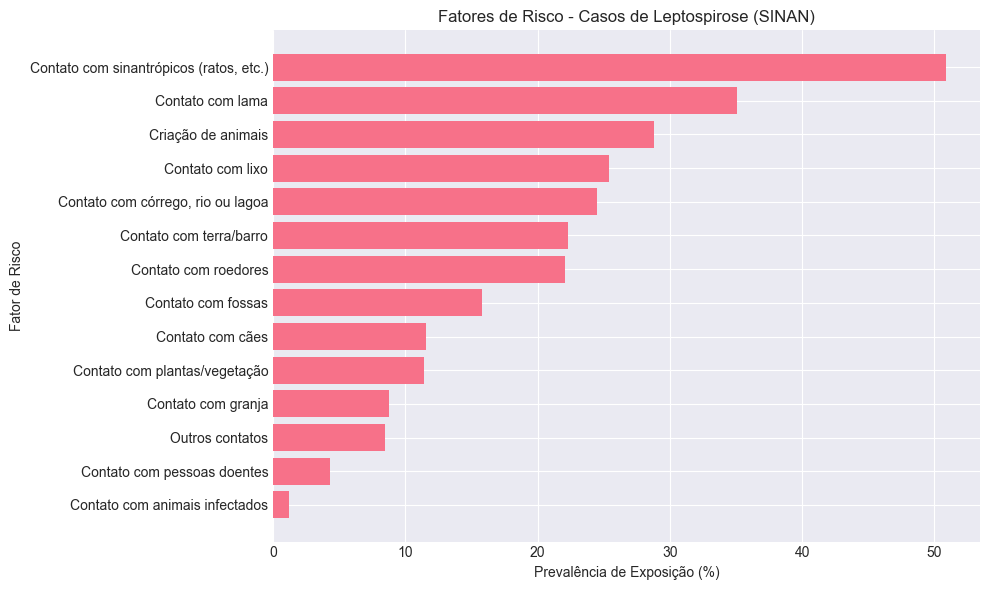

In [14]:
# ============================================================
#  ETAPA 6: ANÁLISE DE FATORES DE RISCO - LEPTOSPIROSE
# ============================================================

print("\n" + "="*80)
print("ETAPA 6: ANÁLISE DE FATORES DE RISCO - LEPTOSPIROSE")
print("="*80)

# 🔹 Variáveis de exposição ambiental e ocupacional
fatores_risco_cols = [
    'ANT_CB_LAM', 'ANT_CB_CRI', 'ANT_CB_CAI', 'ANT_CB_FOS',
    'ANT_CB_SIN', 'ANT_CB_PLA', 'ANT_CB_COR', 'ANT_CB_ROE',
    'ANT_CB_GRA', 'ANT_CB_TER', 'ANT_CB_LIX', 'ANT_CB_OUT',
    'ANT_HUMANO', 'ANT_ANIMAI'
]

# 🔹 Descrições amigáveis dos fatores
fatores_nomes = {
    'ANT_CB_LAM': 'Contato com lama',
    'ANT_CB_CRI': 'Criação de animais',
    'ANT_CB_CAI': 'Contato com cães',
    'ANT_CB_FOS': 'Contato com fossas',
    'ANT_CB_SIN': 'Contato com sinantrópicos (ratos, etc.)',
    'ANT_CB_PLA': 'Contato com plantas/vegetação',
    'ANT_CB_COR': 'Contato com córrego, rio ou lagoa',
    'ANT_CB_ROE': 'Contato com roedores',
    'ANT_CB_GRA': 'Contato com granja',
    'ANT_CB_TER': 'Contato com terra/barro',
    'ANT_CB_LIX': 'Contato com lixo',
    'ANT_CB_OUT': 'Outros contatos',
    'ANT_HUMANO': 'Contato com pessoas doentes',
    'ANT_ANIMAI': 'Contato com animais infectados',
}

# 🔹 Análise de prevalência
exposicoes_data = []
for col in fatores_risco_cols:
    if col in df_clean.columns:
        # Converter para string e limpar espaços
        df_clean[col] = df_clean[col].astype(str).str.strip()
        
        # No SINAN, 1 = Sim, 2 = Não, 9 = Ignorado (ou variações float)
        expostos = df_clean[col].isin(['Sim']).sum()
        nao_expostos = df_clean[col].isin(['Não']).sum()
        ignorados = df_clean[col].isin(['', 'Ignorado']).sum()
        
        total_info = expostos + nao_expostos
        prev = (expostos / total_info * 100) if total_info > 0 else 0
        
        exposicoes_data.append({
            'Fator': fatores_nomes.get(col, col),
            'Expostos': expostos,
            'Não Expostos': nao_expostos,
            'Ignorados': ignorados,
            'Prevalência (%)': round(prev, 1)
        })

# 🔹 DataFrame resumo ordenado
df_exposicoes = (
    pd.DataFrame(exposicoes_data)
    .sort_values('Prevalência (%)', ascending=False)
    .reset_index(drop=True)
)

print("\nRANKING DE FATORES DE RISCO:")
print("-"*80)
print(df_exposicoes.to_string(index=False))

# Opcional: visualização rápida
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df_exposicoes['Fator'], df_exposicoes['Prevalência (%)'])
plt.xlabel('Prevalência de Exposição (%)')
plt.ylabel('Fator de Risco')
plt.title('Fatores de Risco - Casos de Leptospirose (SINAN)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### 7. ANÁLISE DA FORMA CLÍNICA (TARGET POTENCIAL)


#### 7.1 Quantidade de ocorrencia de fatores de risco por CLASSI_FIN

In [15]:

print("\n" + "="*80)
print("ETAPA 7: ANÁLISE DA CLASSI_FIN")
print("="*80)

if 'CLASSI_FIN' in df_clean.columns:
    
    # Casos válidos (excluir ignorado e inconclusivo)
    df_clean['CLASSI_FIN_valido'] = df_clean['CLASSI_FIN'].apply(
        lambda x: x if x in [ 'Confirmado clínico-epidemiológico', 'Confirmado laboratorial'] else np.nan
    )
    
    class_fin_counts = df_clean['CLASSI_FIN_valido'].value_counts()
    total_valido = class_fin_counts.sum()
    
    print("\nDistribuição da Classificação Final:")
    print("-"*80)
    for class_fin in [ 'Confirmado clínico-epidemiológico', 'Confirmado laboratorial']:
        if class_fin in class_fin_counts.index:
            count = class_fin_counts[class_fin]
            print(f"  {class_fin}: {count:,} ({count/total_valido*100:.2f}%)")
    
    invalidos = df_clean['CLASSI_FIN_valido'].isna().sum()
    print(f"\n  Total Válido: {total_valido:,} ({total_valido/len(df_clean)*100:.2f}%)")
    print(f"  Ignorado/Inconclusivo: {invalidos:,} ({invalidos/len(df_clean)*100:.2f}%)")



ETAPA 7: ANÁLISE DA CLASSI_FIN

Distribuição da Classificação Final:
--------------------------------------------------------------------------------

  Total Válido: 0 (0.00%)
  Ignorado/Inconclusivo: 169,935 (100.00%)



ETAPA 7: FATORES DE RISCO × CLASSIFACACAO FINAL DO CASO

PREVALÊNCIA DE ÑConfirm POR FATOR DE RISCO:
--------------------------------------------------------------------------------
                         Fator de Risco  Total  Expostos  ÑExpostos  Descart-expostos  Descart-Ñexpostos  Descart-expostos (%)  Descart-Ñexpostos (%)
          Contato com plantas/vegetação 146000     16589     129411              5668              29853                 34.17                  23.07
                     Contato com granja 145597     12796     132801              4361              31014                 34.08                  23.35
            Contato com pessoas doentes 117110      5000     112110              1650              25530                 33.00                  22.77
      Contato com córrego, rio ou lagoa 146739     35945     110794             11153              24667                 31.03                  22.26
                       Contato com lama 149688     52547      97141

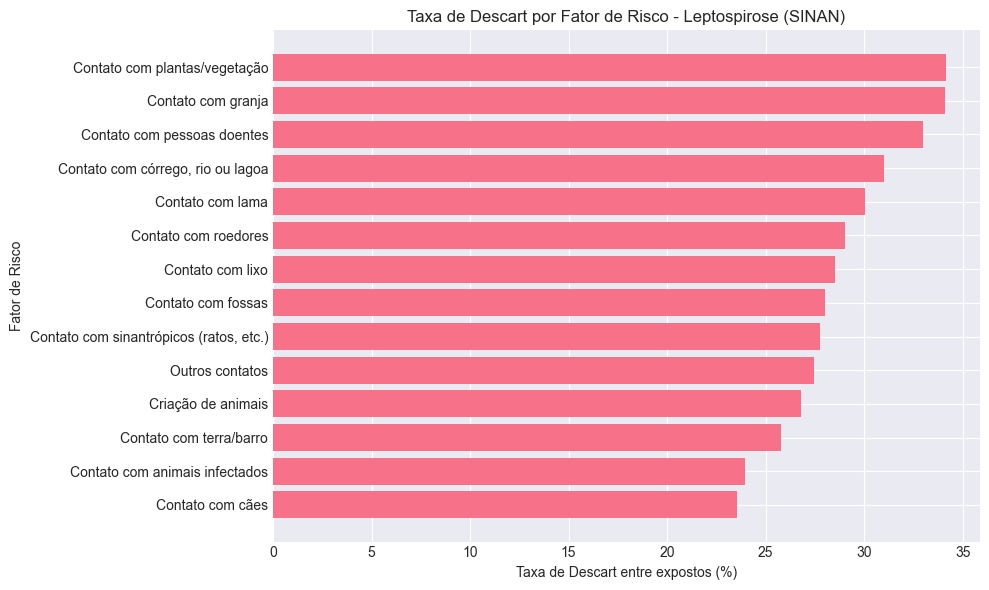

In [16]:
# ============================================================
#  ETAPA 7: FATORES DE RISCO × EVOLUÇÃO DO CASO
# ============================================================

print("\n" + "="*80)
print("ETAPA 7: FATORES DE RISCO × CLASSIFACACAO FINAL DO CASO")
print("="*80)

# 🔹 Dicionário de fatores (mesmo da etapa anterior)
fatores_risco_cols = [
    'ANT_CB_LAM', 'ANT_CB_CRI', 'ANT_CB_CAI', 'ANT_CB_FOS',
    'ANT_CB_SIN', 'ANT_CB_PLA', 'ANT_CB_COR', 'ANT_CB_ROE',
    'ANT_CB_GRA', 'ANT_CB_TER', 'ANT_CB_LIX', 'ANT_CB_OUT',
    'ANT_HUMANO', 'ANT_ANIMAI'
]

fatores_nomes = {
    'ANT_CB_LAM': 'Contato com lama',
    'ANT_CB_CRI': 'Criação de animais',
    'ANT_CB_CAI': 'Contato com cães',
    'ANT_CB_FOS': 'Contato com fossas',
    'ANT_CB_SIN': 'Contato com sinantrópicos (ratos, etc.)',
    'ANT_CB_PLA': 'Contato com plantas/vegetação',
    'ANT_CB_COR': 'Contato com córrego, rio ou lagoa',
    'ANT_CB_ROE': 'Contato com roedores',
    'ANT_CB_GRA': 'Contato com granja',
    'ANT_CB_TER': 'Contato com terra/barro',
    'ANT_CB_LIX': 'Contato com lixo',
    'ANT_CB_OUT': 'Outros contatos',
    'ANT_HUMANO': 'Contato com pessoas doentes',
    'ANT_ANIMAI': 'Contato com animais infectados',
}

# 🔹 Análise de prevalência de óbitos por fator de risco
resultados = []

for col in fatores_risco_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

        # Subconjunto de dados válidos
        df_valid = df_clean[df_clean[col].isin(['Sim', 'Não'])]  # 1=sim, 2=não

        total = len(df_valid)
        expostos = (df_valid[col] == 'Sim').sum()

        # Casos fatais entre expostos e não expostos
        obitos_expostos = df_valid.loc[(df_valid[col] == 'Sim') &
                                       (~df_valid['CLASSI_FIN'].isin(['Descartado']))].shape[0]

        obitos_naoexp = df_valid.loc[(df_valid[col] == 'Não') &
                                     (~df_valid['CLASSI_FIN'].isin(['Descartado']))].shape[0]

        taxa_obito_expostos = (obitos_expostos / expostos * 100) if expostos > 0 else 0
        taxa_obito_naoexp = (obitos_naoexp / (total - expostos) * 100) if (total - expostos) > 0 else 0

        resultados.append({
            'Fator de Risco': fatores_nomes.get(col, col),
            'Total': total,
            'Expostos': expostos,
            'ÑExpostos': total-expostos,
            'Descart-expostos': obitos_expostos,
            'Descart-Ñexpostos': obitos_naoexp,
            'Descart-expostos (%)': round(taxa_obito_expostos, 2),
            'Descart-Ñexpostos (%)': round(taxa_obito_naoexp, 2)
        })
# 🔹 Criar DataFrame ordenado por taxa de óbito entre expostos
df_risco_evolucao = (
    pd.DataFrame(resultados)
    .sort_values('Descart-expostos (%)', ascending=False)
    .reset_index(drop=True)
)

print("\nPREVALÊNCIA DE ÑConfirm POR FATOR DE RISCO:")
print("-"*80)
print(df_risco_evolucao.to_string(index=False))

# 🔹 Visualização opcional
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df_risco_evolucao['Fator de Risco'], df_risco_evolucao['Descart-expostos (%)'])
plt.xlabel('Taxa de Descart entre expostos (%)')
plt.ylabel('Fator de Risco')
plt.title('Taxa de Descart por Fator de Risco - Leptospirose (SINAN)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### 7.2 Quantidade de ocorrencia de fatores de risco por Evolucao

In [17]:
print("\n" + "="*80)
print("ETAPA 7: ANÁLISE DA Evolucao")
print("="*80)

if 'EVOLUCAO' in df_clean.columns:
    
    # Casos válidos (excluir ignorado e inconclusivo)
    df_clean['EVOLUCAO_valido'] = df_clean['EVOLUCAO'].apply(
        lambda x: x if x in [ "Cura","Óbito por leptospirose", "Óbito por outra causa"] else np.nan
    )
    
    forma_counts = df_clean['EVOLUCAO'].value_counts()
    total_valido = forma_counts.sum()
    
    print("\nDistribuição da Forma Clínica (casos válidos):")
    print("-"*80)
    for evolu in [ "Cura","Óbito por leptospirose", "Óbito por outra causa"]:
        if evolu in forma_counts.index:
            count = forma_counts[evolu]
            print(f"  {evolu}: {count:,} ({count/total_valido*100:.2f}%)")
    
    invalidos = df_clean['EVOLUCAO_valido'].isna().sum()
    print(f"\n  Total Válido: {total_valido:,} ({total_valido/len(df_clean)*100:.2f}%)")
    print(f"  Ignorado/Inconclusivo: {invalidos:,} ({invalidos/len(df_clean)*100:.2f}%)")



ETAPA 7: ANÁLISE DA Evolucao

Distribuição da Forma Clínica (casos válidos):
--------------------------------------------------------------------------------
  Cura: 104,934 (61.75%)
  Óbito por leptospirose: 2,846 (1.67%)
  Óbito por outra causa: 10,670 (6.28%)

  Total Válido: 169,935 (100.00%)
  Ignorado/Inconclusivo: 51,485 (30.30%)



ETAPA 7: FATORES DE RISCO × EVOLUÇÃO DO CASO

PREVALÊNCIA DE ÓBITOS POR FATOR DE RISCO:
--------------------------------------------------------------------------------
                         Fator de Risco  Total  Expostos  ÑExpostos  Óbitos-expostos  Óbitos-Ñ expostos  óbito expostos (%)  óbito Ñ expostos (%)
                       Contato com lixo 146534     37260     109274              812               1331                2.18                  1.22
                     Contato com fossas 146369     23084     123285              474               1634                2.05                  1.33
            Contato com pessoas doentes 117110      5000     112110              100               1436                2.00                  1.28
                       Contato com lama 149688     52547      97141             1046               1183                1.99                  1.22
                   Contato com roedores 146168     32338     113830              641               1

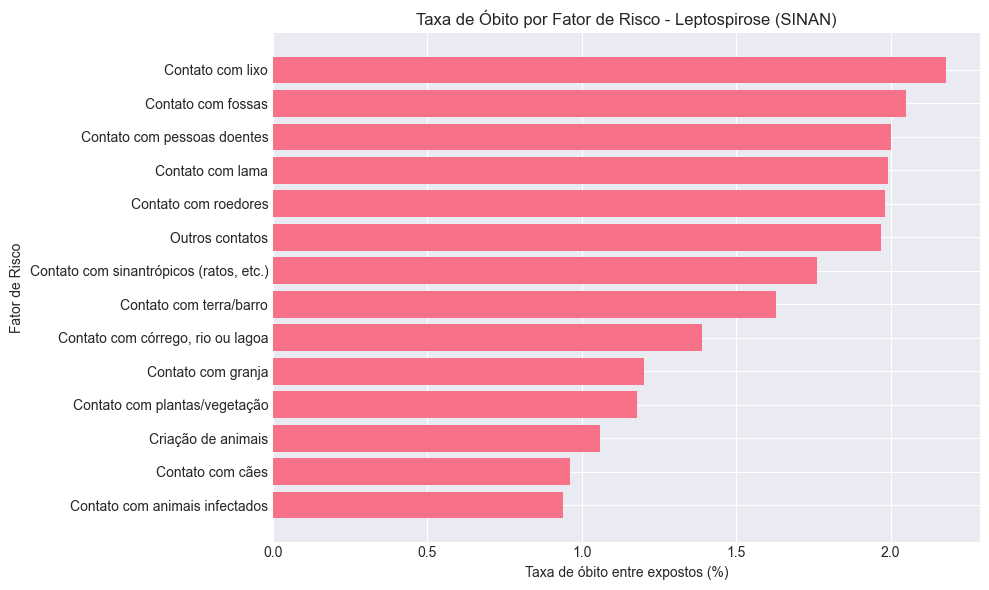

In [18]:
# ============================================================
#  ETAPA 7: FATORES DE RISCO × EVOLUÇÃO DO CASO
# ============================================================

print("\n" + "="*80)
print("ETAPA 7: FATORES DE RISCO × EVOLUÇÃO DO CASO")
print("="*80)

# 🔹 Dicionário de fatores (mesmo da etapa anterior)
fatores_risco_cols = [
    'ANT_CB_LAM', 'ANT_CB_CRI', 'ANT_CB_CAI', 'ANT_CB_FOS',
    'ANT_CB_SIN', 'ANT_CB_PLA', 'ANT_CB_COR', 'ANT_CB_ROE',
    'ANT_CB_GRA', 'ANT_CB_TER', 'ANT_CB_LIX', 'ANT_CB_OUT',
    'ANT_HUMANO', 'ANT_ANIMAI'
]

fatores_nomes = {
    'ANT_CB_LAM': 'Contato com lama',
    'ANT_CB_CRI': 'Criação de animais',
    'ANT_CB_CAI': 'Contato com cães',
    'ANT_CB_FOS': 'Contato com fossas',
    'ANT_CB_SIN': 'Contato com sinantrópicos (ratos, etc.)',
    'ANT_CB_PLA': 'Contato com plantas/vegetação',
    'ANT_CB_COR': 'Contato com córrego, rio ou lagoa',
    'ANT_CB_ROE': 'Contato com roedores',
    'ANT_CB_GRA': 'Contato com granja',
    'ANT_CB_TER': 'Contato com terra/barro',
    'ANT_CB_LIX': 'Contato com lixo',
    'ANT_CB_OUT': 'Outros contatos',
    'ANT_HUMANO': 'Contato com pessoas doentes',
    'ANT_ANIMAI': 'Contato com animais infectados',
}

# 🔹 Análise de prevalência de óbitos por fator de risco
resultados = []

for col in fatores_risco_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

        # Subconjunto de dados válidos
        df_valid = df_clean[df_clean[col].isin(['Sim', 'Não'])]  # 1=sim, 2=não

        total = len(df_valid)
        expostos = (df_valid[col] == 'Sim').sum()

        # Casos fatais entre expostos e não expostos
        obitos_expostos = df_valid.loc[(df_valid[col] == 'Sim') &
                                       (df_valid['EVOLUCAO'].isin(['Óbito por leptospirose']))].shape[0]

        obitos_naoexp = df_valid.loc[(df_valid[col] == 'Não') &
                                     (df_valid['EVOLUCAO'].isin(['Óbito por leptospirose']))].shape[0]

        taxa_obito_expostos = (obitos_expostos / expostos * 100) if expostos > 0 else 0
        taxa_obito_naoexp = (obitos_naoexp / (total - expostos) * 100) if (total - expostos) > 0 else 0

        resultados.append({
            'Fator de Risco': fatores_nomes.get(col, col),
            'Total': total,
            'Expostos': expostos,
            'ÑExpostos': total-expostos,
            'Óbitos-expostos': obitos_expostos,
            'Óbitos-Ñ expostos': obitos_naoexp,
            'óbito expostos (%)': round(taxa_obito_expostos, 2),
            'óbito Ñ expostos (%)': round(taxa_obito_naoexp, 2)
        })
# 🔹 Criar DataFrame ordenado por taxa de óbito entre expostos
df_risco_evolucao = (
    pd.DataFrame(resultados)
    .sort_values('óbito expostos (%)', ascending=False)
    .reset_index(drop=True)
)

print("\nPREVALÊNCIA DE ÓBITOS POR FATOR DE RISCO:")
print("-"*80)
print(df_risco_evolucao.to_string(index=False))

# 🔹 Visualização opcional
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df_risco_evolucao['Fator de Risco'], df_risco_evolucao['óbito expostos (%)'])
plt.xlabel('Taxa de óbito entre expostos (%)')
plt.ylabel('Fator de Risco')
plt.title('Taxa de Óbito por Fator de Risco - Leptospirose (SINAN)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### 8. FEATURE ENGINEERING - VARIÁVEIS DERIVADAS

In [19]:
def criar_variaveis_sociais_climaticas(df):
    df = df.copy()

    # Vulnerabilidade social combinada
    
    # Critérios:
    # - Baixa escolaridade (até fundamental incompleto)
    # - Raça vulnerável (preta, parda, indígena)
    # - Faixa etária vulnerável (<=15 ou >=60)
  
    df['baixa_escolaridade'] = df['CS_ESCOL_N'].isin(['Sem escolaridade', 
                                                      '1ª a 4ª série incompleta do EF', 
                                                      '4ª série completa do EF',
                                                      '5ª a 8ª série incompleta do EF']).astype(int)
    df['raca_vulneravel'] = df['CS_RACA'].isin(['Preta', 'Parda', 'Indígena']).astype(int)
    df['faixa_vulneravel'] = np.where((df['NU_IDADE_N'] <= 15) | (df['NU_IDADE_N'] >= 60), 1, 0)

    # Índice de vulnerabilidade social (soma simples)
    df['vulnerabilidade_social'] = (
        df['baixa_escolaridade'] + df['raca_vulneravel'] + df['faixa_vulneravel']
    )

    # Classificação categórica
    df['nivel_vulnerabilidade'] = pd.cut(
        df['vulnerabilidade_social'],
        bins=[-1, 0, 1, 3],
        labels=['Baixa', 'Moderada', 'Alta']
    )

    # Flag binária para alta vulnerabilidade
    df['alta_vulnerabilidade'] = (df['nivel_vulnerabilidade'] == 'Alta').astype(int)

    # ---------------------------------------------
    # Variáveis sazonais (chuvas e clima)
    # ---------------------------------------------
    df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], errors='coerce')
    df['mes_sintomas'] = df['DT_SIN_PRI'].dt.month
    df['semana_sintomas'] = df['DT_SIN_PRI'].dt.isocalendar().week

    # Estação do ano (Hemisfério Sul)
    def estacao(m):
        if m in [12, 1, 2]:
            return 'Verão'
        elif m in [3, 4, 5]:
            return 'Outono'
        elif m in [6, 7, 8]:
            return 'Inverno'
        elif m in [9, 10, 11]:
            return 'Primavera'
        return np.nan

    df['estacao'] = df['mes_sintomas'].apply(estacao)

    # Meses mais chuvosos (Brasil: verão e início do outono)
    df['periodo_chuvoso'] = df['mes_sintomas'].isin([11, 12, 1, 2, 3, 4]).astype(int)

    return df


In [20]:
df_processed=criar_variaveis_sociais_climaticas(df_clean)

# Visualizar resultado
cols_exemplo = [
    'NU_IDADE_N', 'CS_RACA', 'CS_ESCOL_N',
    'baixa_escolaridade','raca_vulneravel','faixa_vulneravel',
    'vulnerabilidade_social', 'nivel_vulnerabilidade',
    'mes_sintomas',
    'estacao', 'periodo_chuvoso',
    
]
display(df_processed[cols_exemplo].head(100))


,NU_IDADE_N,CS_RACA,CS_ESCOL_N,baixa_escolaridade,raca_vulneravel,faixa_vulneravel,vulnerabilidade_social,nivel_vulnerabilidade,mes_sintomas,estacao,periodo_chuvoso
0,11.0,Não informado,Não informado,0,0,1,1,Moderada,12,Verão,1
1,4.0,Parda,10,0,1,1,2,Alta,12,Verão,1
2,50.0,Branca,1ª a 4ª série incompleta do EF,1,0,0,1,Moderada,1,Verão,1
3,18.0,Branca,Ensino médio completo,0,0,0,0,Baixa,12,Verão,1
4,31.0,Branca,Ensino médio incompleto,0,0,0,0,Baixa,12,Verão,1
5,13.0,Branca,Ensino fundamental completo,0,0,1,1,Moderada,12,Verão,1
6,25.0,Branca,Superior incompleto,0,0,0,0,Baixa,12,Verão,1
7,54.0,Branca,Ensino médio completo,0,0,0,0,Baixa,12,Verão,1
8,41.0,Não informado,Ensino médio completo,0,0,0,0,Baixa,12,Verão,1
9,21.0,Parda,Não informado,0,1,0,1,Moderada,12,Verão,1


8.5 Inserir id de ocupação não informado

In [25]:
df_processed['ID_OCUPA_N'] = df_clean['ID_OCUPA_N'].fillna("Não informado")

#### 9. SUMÁRIO FINAL

In [22]:
print("\n" + "="*80)
print("SUMÁRIO FINAL DO DATASET LIMPO")
print("="*80)

print(f"\n• Total de registros: {len(df_clean):,}")
print(f"• Total de colunas: {df_clean.shape[1]}")
print(f"• Tamanho em memória: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



SUMÁRIO FINAL DO DATASET LIMPO

• Total de registros: 169,935
• Total de colunas: 118
• Tamanho em memória: 1464.75 MB


In [23]:
# Contar valores faltantes e calcular percentual por coluna
# Definir valores que serão considerados "faltantes"
valores_faltantes = ["", " ", "  ", "NA", "N/A", "nan", "None"]

# Substituir esses valores por NaN
df_clean = df_clean.replace(valores_faltantes, np.nan)

faltantes = (
    df_clean.isna()
    .sum()
    .reset_index()
    .rename(columns={'index': 'Coluna', 0: 'Faltantes'})
)
faltantes["% Faltantes"] = (faltantes["Faltantes"] / len(df_clean) * 100).round(2)

# Exibir apenas colunas com faltantes
faltantes = faltantes.query("Faltantes > 0").sort_values("% Faltantes", ascending=False)

print("📋 Quantidade de valores faltantes por coluna:")
display(faltantes.head(30))  # mostra as 20 piores


📋 Quantidade de valores faltantes por coluna:


,Coluna,Faltantes,% Faltantes
116,CLASSI_FIN_valido,169935,100.0
117,EVOLUCAO_valido,51485,30.3
115,faixa_etaria,5,0.0


In [27]:
df_processed.to_parquet('processed/df_hepat_processed_v1.parquet')